## Model Monitor

This notebook evaluates the stability of a trained XGBoost model by computing AUC, GINI, and PSI across training, test, and OOT datasets. The results show good performance during training (AUC ~0.955) and testing (AUC ~0.839). However, the monitoring phase indicates severe data drift (Total PSI = 8.05), likely due to new population segments, suggesting that model retraining is needed.

In [38]:
import os
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [39]:
# Build a .py script that takes a snapshot date, loads a model artefact and make an inference and save to datamart

## set up pyspark session

In [40]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

## set up config

In [41]:
# set up config
model_train_date_str = "2024-09-01"
snapshot_date_str = "2024-01-01"
model_name = "credit_model_2024_09_01.pkl"
train_test_period_months = 12
oot_period_months = 2
train_test_ratio = 0.8
config = {}
config["snapshot_date_str"] = snapshot_date_str
config["snapshot_date"] = datetime.strptime(config["snapshot_date_str"], "%Y-%m-%d")
config["model_name"] = model_name
config["model_bank_directory"] = "model_bank/"
config["model_artefact_filepath"] = config["model_bank_directory"] + config["model_name"]
config["model_train_date_str"] = model_train_date_str
config["train_test_period_months"] = train_test_period_months
config["oot_period_months"] =  oot_period_months
config["model_train_date"] =  datetime.strptime(model_train_date_str, "%Y-%m-%d")
config["oot_end_date"] =  config['model_train_date'] - timedelta(days = 1)
config["oot_start_date"] =  config['model_train_date'] - relativedelta(months = oot_period_months)
config["train_test_end_date"] =  config["oot_start_date"] - timedelta(days = 1)
config["train_test_start_date"] =  config["oot_start_date"] - relativedelta(months = train_test_period_months)
config["train_test_ratio"] = train_test_ratio 

## load model artefact from model bank

In [42]:
# Load the model from the pickle file
with open(config["model_artefact_filepath"], 'rb') as file:
    model_artefact = pickle.load(file)

print("Model loaded successfully! " + config["model_artefact_filepath"])

Model loaded successfully! model_bank/credit_model_2024_09_01.pkl


## load data from gold table

In [43]:
def read_gold_table(table, gold_db, spark):
    """
    Helper function to read all partitions of a gold table
    """
    folder_path = os.path.join(gold_db, table)
    files_list = [os.path.join(folder_path, os.path.basename(f)) for f in glob.glob(os.path.join(folder_path, '*'))]
    df = spark.read.option("header", "true").parquet(*files_list)
    return df

X_spark = read_gold_table('feature_store', 'datamart/gold', spark)
y_spark = read_gold_table('label_store', 'datamart/gold', spark)
X_df = X_spark.toPandas().sort_values(by='customer_id')
y_df = y_spark.toPandas().sort_values(by='customer_id')

# Consider data from model training date
# Makesure snapshot_date tyoes are the same
y_df['snapshot_date'] = pd.to_datetime(y_df['snapshot_date'])
X_df['snapshot_date'] = pd.to_datetime(X_df['snapshot_date'])

y_model_df = y_df[(y_df['snapshot_date'] >= config['train_test_start_date']) & (y_df['snapshot_date'] <= config['model_train_date'])]
X_model_df = X_df[np.isin(X_df['customer_id'], y_model_df['customer_id'].unique())]

# Create OOT split
y_oot = y_model_df[(y_model_df['snapshot_date'] >= config['oot_start_date']) & (y_model_df['snapshot_date'] <= config['oot_end_date'])]
X_oot = X_model_df[np.isin(X_model_df['customer_id'], y_oot['customer_id'].unique())]

# Everything else goes into train-test
y_traintest = y_model_df[y_model_df['snapshot_date'] <= config['train_test_end_date']]
X_traintest = X_model_df[np.isin(X_model_df['customer_id'], y_traintest['customer_id'].unique())]

X_train, X_test, y_train, y_test = train_test_split(X_traintest, y_traintest, 
                                                    test_size=config['train_test_ratio'], 
                                                    random_state=88, 
                                                    shuffle=True, 
                                                    stratify=y_traintest['label'])

print('X_oot', X_oot.shape[0])
print('y_oot', y_oot.shape[0], round(y_test['label'].mean(), 2))

X_oot

X_oot 1003
y_oot 1003 0.28


,customer_id,snapshot_date,age,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,delay_from_due_date,...,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20
1596,CUS_0x102d,2024-01-01,31,89064.523438,7256.043457,5.0,3.0,1.0,1.0,6,...,84.461538,96.461538,100.615385,102.615385,79.923077,52.076923,107.615385,96.923077,109.000000,75.538462
3434,CUS_0x1048,2024-02-01,27,42387.539062,3680.294922,3.0,7.0,26.0,7.0,9,...,103.071429,123.142857,116.000000,82.000000,87.428571,101.142857,77.142857,105.357143,90.285714,111.285714
1597,CUS_0x1051,2024-01-01,42,35022.218750,2859.518311,3.0,5.0,4.0,1.0,6,...,106.384615,117.538462,28.538462,148.153846,66.461538,60.538462,114.846154,150.538462,98.461538,88.076923
3435,CUS_0x10c0,2024-02-01,39,49454.128906,4328.177734,8.0,5.0,23.0,2.0,59,...,156.142857,118.214286,74.000000,94.357143,84.285714,44.142857,29.714286,144.714286,89.285714,89.000000
1023,CUS_0x115c,2024-02-01,20,41695.761719,3401.646729,6.0,7.0,15.0,9.0,24,...,81.642857,75.928571,148.357143,80.357143,108.071429,99.357143,105.000000,113.357143,99.000000,134.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217,CUS_0xec4,2024-02-01,53,38041.558594,2972.129883,5.0,10.0,10.0,3.0,9,...,129.071429,114.571429,145.071429,76.857143,75.214286,57.428571,100.000000,112.928571,151.857143,89.642857
3555,CUS_0xf6c,2024-02-01,55,76046.250000,6082.187500,7.0,3.0,16.0,3.0,17,...,89.214286,108.428571,90.428571,97.714286,71.500000,86.571429,85.500000,123.714286,98.500000,107.714286
1783,CUS_0xf9e,2024-01-01,43,142475.312500,12013.943359,8.0,5.0,11.0,2.0,23,...,81.769231,60.538462,104.538462,93.692308,57.923077,105.692308,30.307692,80.230769,105.615385,102.538462
7701,CUS_0xfa4,2024-02-01,40,15035.190430,1214.932495,9.0,10.0,33.0,5.0,61,...,97.142857,111.357143,99.357143,144.714286,105.928571,87.357143,157.214286,66.142857,109.285714,129.500000


In [57]:
# Transform data into numpy arrays
X_train_arr = X_train.drop(columns=['customer_id', 'snapshot_date']).values
X_test_arr = X_test.drop(columns=['customer_id', 'snapshot_date']).values
X_oot_arr = X_oot.drop(columns=['customer_id', 'snapshot_date']).values

y_train_arr = y_train['label'].values
y_test_arr = y_test['label'].values
y_oot_arr = y_oot['label'].values

In [58]:
transformer_stdscaler = model_artefact['preprocessing_transformers']['stdscaler']

X_monitor_df = X_oot.copy()
X_monitor_ordered = X_monitor_df[model_artefact["feature_columns"]]
X_monitor_arr = X_monitor_ordered.values

X_monitor = model_artefact['preprocessing_transformers']['stdscaler'].transform(X_oot_arr)

## Model Monitor

In [59]:
# load model
model = model_artefact["model"]

# predict model
y_monitor = model.predict_proba(X_monitor)[:, 1]

# output
y_monitor_pdf = X_monitor_df[["customer_id", "snapshot_date"]].copy()
y_monitor_pdf["model_name"] = model_artefact["model_version"]
y_monitor_pdf["model_predictions"] = y_monitor

y_monitor_pdf.head()

,customer_id,snapshot_date,model_name,model_predictions
1596,CUS_0x102d,2024-01-01,credit_model_2024_09_01,0.044226
3434,CUS_0x1048,2024-02-01,credit_model_2024_09_01,0.866463
1597,CUS_0x1051,2024-01-01,credit_model_2024_09_01,0.074630
3435,CUS_0x10c0,2024-02-01,credit_model_2024_09_01,0.893184
1023,CUS_0x115c,2024-02-01,credit_model_2024_09_01,0.365190


In [81]:
model = model_artefact["model"]

# monitor 
y_pred_proba = model.predict_proba(X_monitor_arr)[:, 1]
test_auc_score = roc_auc_score(y_oot_arr, y_pred_proba)  # 注意这里用 y_oot_arr
print("Test AUC score: ", test_auc_score)
print("Test GINI score: ", round(2 * test_auc_score - 1, 3))

# oot 
y_pred_proba_oot = model.predict_proba(X_oot_arr)[:, 1]
oot_auc_score = roc_auc_score(y_oot_arr, y_pred_proba_oot)
print("OOT AUC score: ", oot_auc_score)
print("OOT GINI score: ", round(2 * oot_auc_score - 1, 3))


Test AUC score:  0.40458608440480326
Test GINI score:  -0.191
OOT AUC score:  0.40458608440480326
OOT GINI score:  -0.191


In [82]:
def calculate_psi(expected_array, actual_array, buckets=10):
    expected = pd.Series(expected_array)
    actual = pd.Series(actual_array)

    # 改成固定 bin：适合概率预测分布
    bin_edges = np.linspace(0, 1, buckets + 1)

    expected_bins = pd.cut(expected, bins=bin_edges, include_lowest=True)
    actual_bins = pd.cut(actual, bins=bin_edges, include_lowest=True)

    expected_perc = expected_bins.value_counts(normalize=True).sort_index().replace(0, 1e-6)
    actual_perc = actual_bins.value_counts(normalize=True).sort_index().replace(0, 1e-6)

    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)

    psi_df = pd.DataFrame({
        'Bin': expected_perc.index.astype(str),
        'Expected_Percentage': expected_perc.values,
        'Actual_Percentage': actual_perc.values,
        'PSI_Value': psi_values.values
    })

    psi_value = psi_values.sum()

    return psi_df, psi_value


In [83]:
psi_df, psi_value = calculate_psi(y_train_arr, y_monitor)

print(psi_df)
print(f"Total PSI: {psi_value:.4f}")

             Bin  Expected_Percentage  Actual_Percentage  PSI_Value
0  (-0.001, 0.1]             0.717045           0.413759   0.166763
1     (0.1, 0.2]             0.000001           0.171486   2.066775
2     (0.2, 0.3]             0.000001           0.101695   1.172504
3     (0.3, 0.4]             0.000001           0.072782   0.814795
4     (0.4, 0.5]             0.000001           0.045862   0.492249
5     (0.5, 0.6]             0.000001           0.052841   0.574643
6     (0.6, 0.7]             0.000001           0.051844   0.562813
7     (0.7, 0.8]             0.000001           0.047856   0.515688
8     (0.8, 0.9]             0.000001           0.038883   0.410921
9     (0.9, 1.0]             0.282955           0.002991   1.273747
Total PSI: 8.0509


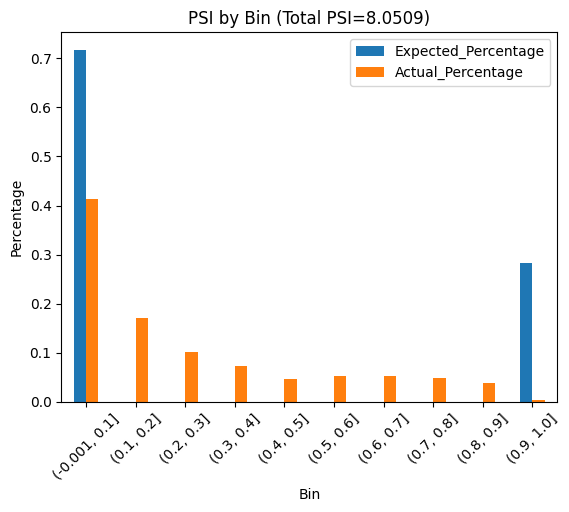

In [84]:
import matplotlib.pyplot as plt

def plot_psi(psi_df):
    psi_df.plot(x='Bin', y=['Expected_Percentage', 'Actual_Percentage'], kind='bar')
    plt.title(f"PSI by Bin (Total PSI={psi_df['PSI_Value'].sum():.4f})")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.show()

plot_psi(psi_df)

Total PSI = 8.05。
This is very high, indicating that the monitoring distribution has significantly drifted from the training distribution. Typically, a PSI greater than 0.25 already suggests attention is needed, and the value far exceeds this threshold.
The training distribution is mainly concentrated at low and high score segments， whereas the monitoring data is mostly concentrated in the middle probability range. This indicates that the model's scoring on new data has shifted significantly.
It is possible that a new customer segment has entered, resulting in significant distribution drift. This indicates that model retraining may be necessary to adapt to the new data characteristics.

## Save model monitor to datamart gold table

In [ ]:
# create bronze datalake
gold_directory = f"datamart/gold/model_monitors/{config["model_name"][:-4]}/"
print(gold_directory)

if not os.path.exists(gold_directory):
    os.makedirs(gold_directory)

# save gold table - IRL connect to database to write
partition_name = config["model_name"][:-4] + "_monitorss_" + snapshot_date_str.replace('-','_') + '.parquet'
filepath = gold_directory + partition_name
spark.createDataFrame(y_monitor_pdf).write.mode("overwrite").parquet(filepath)
# df.toPandas().to_parquet(filepath,
#           compression='gzip')
print('saved to:', filepath)